In [7]:
!unzip -q img_align_celeba.zip -d celeba_data

replace celeba_data/img_align_celeba/000001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [1]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [2]:
# images load => transform => dataset of all imags
class ImageProcessor:
    def __init__(self, root_dir_path , transformations= None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        #list of path of all images
        self.all_img_paths = [os.path.join(root_dir_path,img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self,idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img =  self.transformations(img)

        return img

In [5]:
root_dir_path = "celeba_data/img_align_celeba"
transformations = transforms.Compose([
    transforms.CenterCrop(178),#175 *175
    transforms.Resize(64),# 65*65
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))#[-1,1]
])

In [6]:
dataset = ImageProcessor(root_dir_path,transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


## generate network

In [9]:
import numpy as np
import torch.nn as nn
import torch.optim as optim

In [10]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels),
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64)
        return img

## Discriminator Network

In [11]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D

            nn.Linear(img_channels*64*64,1024),
            nn.LeakyReLU(),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(),

            nn.Linear(256,1),
            nn.Sigmoid() # for probability
        )

    def forward(self,img):
        return self.model(img)

In [12]:
GAN_loss = nn.BCELoss()
generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr = 0.0002,betas = (0.5, 0.999))
discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr = 0.0002,betas = (0.5, 0.999))


In [13]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cuda


In [14]:
generator = generator.to(device)
discriminator = discriminator.to(device)

In [15]:
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

## Training The Model

In [16]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)

            # 1. Fixed: Changed real_img to real_imgs
            batch_size = real_imgs.size(0)

            # creates real images labels & fake images labels
            real_labels = torch.ones(batch_size, 1).to(device) #[1,1,1,...]
            fake_labels = torch.zeros(batch_size, 1).to(device) #[0,0,0,...]

            # train the discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device)) # Added .to(device) here for noise
            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            d_optimizer.step()

            # train the generator
            g_optimizer.zero_grad()
            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                # 2. Fixed: Changed {epoch} to {epochs}
                print(f"for epoch: {epoch+1}/{epochs}...batch: {i+1}...G_loss:{g_loss.item():.4f}...D_loss:{d_loss.item():.4f}")

         # saves generated img for each epoch
        save_generated_images(generator, epoch, device)

for epoch: 1/5...batch: 1...G_loss:0.6812...D_loss:0.6953
for epoch: 1/5...batch: 51...G_loss:1.0346...D_loss:0.3009
for epoch: 1/5...batch: 101...G_loss:0.6307...D_loss:0.4058
for epoch: 1/5...batch: 151...G_loss:0.8274...D_loss:0.3649
for epoch: 1/5...batch: 201...G_loss:1.3984...D_loss:0.2462
for epoch: 1/5...batch: 251...G_loss:0.9688...D_loss:0.2774
for epoch: 1/5...batch: 301...G_loss:1.1897...D_loss:0.2122
for epoch: 1/5...batch: 351...G_loss:0.8035...D_loss:0.3009
for epoch: 1/5...batch: 401...G_loss:1.2291...D_loss:0.3411
for epoch: 1/5...batch: 451...G_loss:2.1166...D_loss:0.2618
for epoch: 1/5...batch: 501...G_loss:2.6142...D_loss:0.3668
for epoch: 1/5...batch: 551...G_loss:1.0202...D_loss:0.1785
for epoch: 1/5...batch: 601...G_loss:2.7617...D_loss:0.0460
for epoch: 1/5...batch: 651...G_loss:3.5118...D_loss:0.0985
for epoch: 1/5...batch: 701...G_loss:5.0873...D_loss:0.1631
for epoch: 1/5...batch: 751...G_loss:1.7661...D_loss:0.2031
for epoch: 1/5...batch: 801...G_loss:3.2141

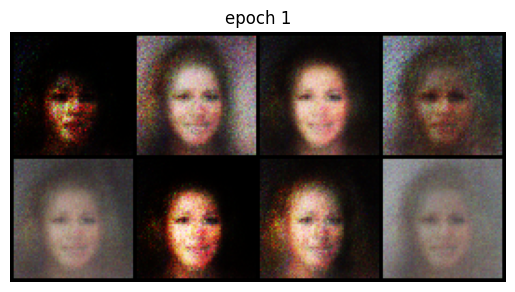

for epoch: 2/5...batch: 1...G_loss:1.8209...D_loss:0.3557
for epoch: 2/5...batch: 51...G_loss:2.9621...D_loss:0.3555
for epoch: 2/5...batch: 101...G_loss:4.1958...D_loss:0.3697
for epoch: 2/5...batch: 151...G_loss:3.1798...D_loss:0.4004
for epoch: 2/5...batch: 201...G_loss:2.5200...D_loss:0.3091
for epoch: 2/5...batch: 251...G_loss:2.1506...D_loss:0.3506
for epoch: 2/5...batch: 301...G_loss:2.1422...D_loss:0.4041
for epoch: 2/5...batch: 351...G_loss:2.5156...D_loss:0.3210
for epoch: 2/5...batch: 401...G_loss:2.3919...D_loss:0.2597
for epoch: 2/5...batch: 451...G_loss:2.9024...D_loss:0.2632
for epoch: 2/5...batch: 501...G_loss:2.7090...D_loss:0.2188
for epoch: 2/5...batch: 551...G_loss:1.8722...D_loss:0.2954
for epoch: 2/5...batch: 601...G_loss:2.7951...D_loss:0.2273
for epoch: 2/5...batch: 651...G_loss:1.9556...D_loss:0.4225
for epoch: 2/5...batch: 701...G_loss:2.8880...D_loss:0.2180
for epoch: 2/5...batch: 751...G_loss:1.7702...D_loss:0.3495
for epoch: 2/5...batch: 801...G_loss:2.9479

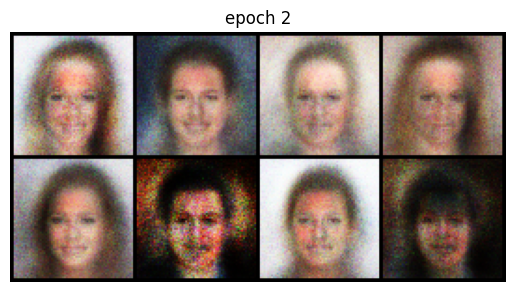

for epoch: 3/5...batch: 1...G_loss:1.5482...D_loss:0.4651
for epoch: 3/5...batch: 51...G_loss:2.3727...D_loss:0.4150
for epoch: 3/5...batch: 101...G_loss:2.2914...D_loss:0.4211
for epoch: 3/5...batch: 151...G_loss:2.2975...D_loss:0.3360
for epoch: 3/5...batch: 201...G_loss:2.1860...D_loss:0.4966
for epoch: 3/5...batch: 251...G_loss:2.1880...D_loss:0.3964
for epoch: 3/5...batch: 301...G_loss:1.8676...D_loss:0.3953
for epoch: 3/5...batch: 351...G_loss:2.0176...D_loss:0.5054
for epoch: 3/5...batch: 401...G_loss:2.1253...D_loss:0.4044
for epoch: 3/5...batch: 451...G_loss:1.6230...D_loss:0.3578
for epoch: 3/5...batch: 501...G_loss:2.0289...D_loss:0.3796
for epoch: 3/5...batch: 551...G_loss:1.7559...D_loss:0.4738
for epoch: 3/5...batch: 601...G_loss:1.9096...D_loss:0.4537
for epoch: 3/5...batch: 651...G_loss:1.7924...D_loss:0.3765
for epoch: 3/5...batch: 701...G_loss:1.7942...D_loss:0.4516
for epoch: 3/5...batch: 751...G_loss:2.1461...D_loss:0.4609
for epoch: 3/5...batch: 801...G_loss:1.7835

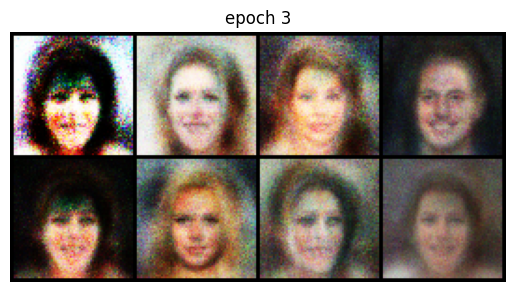

for epoch: 4/5...batch: 1...G_loss:1.4872...D_loss:0.3843
for epoch: 4/5...batch: 51...G_loss:1.8545...D_loss:0.4532
for epoch: 4/5...batch: 101...G_loss:1.7937...D_loss:0.4039
for epoch: 4/5...batch: 151...G_loss:1.6140...D_loss:0.4606
for epoch: 4/5...batch: 201...G_loss:1.4704...D_loss:0.5064
for epoch: 4/5...batch: 251...G_loss:1.5297...D_loss:0.3922
for epoch: 4/5...batch: 301...G_loss:1.5908...D_loss:0.4418
for epoch: 4/5...batch: 351...G_loss:1.3760...D_loss:0.4971
for epoch: 4/5...batch: 401...G_loss:1.6770...D_loss:0.4386
for epoch: 4/5...batch: 451...G_loss:1.4631...D_loss:0.4858
for epoch: 4/5...batch: 501...G_loss:1.7714...D_loss:0.5272
for epoch: 4/5...batch: 551...G_loss:1.7315...D_loss:0.3595
for epoch: 4/5...batch: 601...G_loss:1.8509...D_loss:0.4735
for epoch: 4/5...batch: 651...G_loss:1.6008...D_loss:0.5220
for epoch: 4/5...batch: 701...G_loss:1.6780...D_loss:0.5378
for epoch: 4/5...batch: 751...G_loss:1.6020...D_loss:0.4389
for epoch: 4/5...batch: 801...G_loss:1.4501

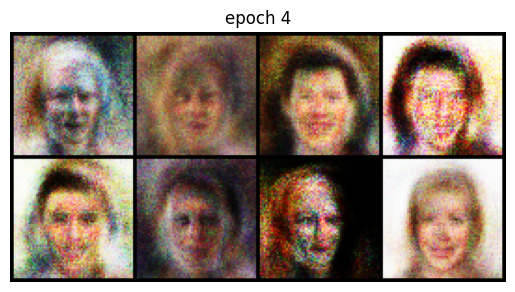

for epoch: 5/5...batch: 1...G_loss:1.2892...D_loss:0.5312
for epoch: 5/5...batch: 51...G_loss:1.5356...D_loss:0.5442
for epoch: 5/5...batch: 101...G_loss:1.5339...D_loss:0.4691
for epoch: 5/5...batch: 151...G_loss:1.4939...D_loss:0.4575
for epoch: 5/5...batch: 201...G_loss:1.5023...D_loss:0.6881
for epoch: 5/5...batch: 251...G_loss:1.5258...D_loss:0.4408
for epoch: 5/5...batch: 301...G_loss:1.3503...D_loss:0.5115
for epoch: 5/5...batch: 351...G_loss:1.4481...D_loss:0.5048
for epoch: 5/5...batch: 401...G_loss:1.6255...D_loss:0.4715
for epoch: 5/5...batch: 451...G_loss:1.5015...D_loss:0.5423
for epoch: 5/5...batch: 501...G_loss:1.6098...D_loss:0.5423
for epoch: 5/5...batch: 551...G_loss:1.4972...D_loss:0.5020
for epoch: 5/5...batch: 601...G_loss:1.3852...D_loss:0.4747
for epoch: 5/5...batch: 651...G_loss:1.5586...D_loss:0.5025
for epoch: 5/5...batch: 701...G_loss:1.2608...D_loss:0.5180
for epoch: 5/5...batch: 751...G_loss:1.3910...D_loss:0.5993
for epoch: 5/5...batch: 801...G_loss:1.5784

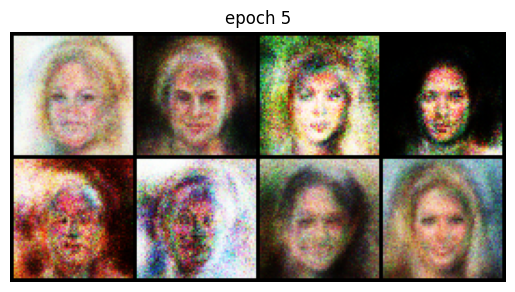

In [17]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

train(generator, discriminator, dataloader, epochs=5)